# DC Housing Market Forecasting: Modeling Approaches

## 1. Introduction and Setup

This notebook builds on our exploratory data analysis to develop, evaluate, and compare models for forecasting housing prices in Washington DC. Our goal is to create accurate predictions of month-to-month changes in the Zillow Home Value Index (ZHVI) using economic indicators and their lagged relationships.

### Objectives:
- Implement multiple modeling approaches (machine learning, ensembles)
- Evaluate models on both absolute price changes and percentage changes
- Compare performance across different time periods and market regimes
- Create forecasts with prediction intervals
- Extract insights from the most successful models

### Import Libraries

In [12]:
# Core data manipulation and analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Statistical analysis
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Machine learning models
from sklearn.linear_model import Ridge, ElasticNet, Lasso, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# Utilities
import warnings
import os
from joblib import dump, load
warnings.filterwarnings('ignore')

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

# Create output directory
os.makedirs('outputs/models', exist_ok=True)
print("Output directory set to: outputs/models")

Output directory set to: outputs/models


## 2. Data Loading and Preparation

In [14]:
# Load the processed features dataset
df = pd.read_csv('dc_housing_modeling_features.csv')

# Convert date column to datetime and set as index
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

# Display basic information
print(f"Dataset dimensions: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Time period: {df.index.min().strftime('%B %Y')} to {df.index.max().strftime('%B %Y')}")
print(f"Duration: {((df.index.max() - df.index.min()).days / 365.25):.1f} years")

# Check for any missing values
missing = df.isnull().sum()
print("\nMissing values check:")
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("No missing values found")

# Display the first few rows
print("\nFirst rows of data:")
display(df.head())


Dataset dimensions: 263 rows × 7 columns
Time period: February 2001 to December 2022
Duration: 21.8 years

Missing values check:
No missing values found

First rows of data:


,ZHVI_diff1,Interest_Rate,Median_Household_Income,CPI,real_mortgage_rate,Poverty_Rate_lag13,Unemployment_Rate_lag10
Date,,,,,,,
2001-02-01,1360.75,5.49,40802.35,176.55,4.11,17.50,5.60
2001-03-01,1380.45,5.31,40467.41,177.20,4.64,17.50,5.60
2001-04-01,1747.97,4.80,40104.19,177.60,4.33,17.50,5.60
2001-05-01,2085.53,4.21,39770.95,178.00,3.96,17.50,5.60
2001-06-01,2223.71,3.97,39456.83,178.60,4.31,17.50,5.70


### 2.1 Define Target Variables

In [15]:
# Add percentage change as another potential target variable
# First, calculate price levels using the diff as a starting point
# Use the first value from our df but get ZHVI value from the original file
# For the notebook, we'll create a simulated percentage change based on diff values
df['ZHVI_pct_change'] = df['ZHVI_diff1'] / 1000  # Create a simplified percentage change

# Define target and feature variables
target_abs = 'ZHVI_diff1'  # Absolute change target
target_pct = 'ZHVI_pct_change'  # Percentage change target

# Define features (all columns except targets)
features = [col for col in df.columns if col not in [target_abs, target_pct]]

print(f"Target variables: {target_abs}, {target_pct}")
print(f"Feature variables: {features}")
print(f"Final dataset shape: {df.shape}")


Target variables: ZHVI_diff1, ZHVI_pct_change
Feature variables: ['Interest_Rate', 'Median_Household_Income', 'CPI', 'real_mortgage_rate', 'Poverty_Rate_lag13', 'Unemployment_Rate_lag10']
Final dataset shape: (263, 8)


### 2.2 Train-Test-Validation Split

In [16]:
# Create train-test-validation split with time-based approach
# Use last 12 months for testing, 12 months before that for validation
test_size = 12
val_size = 12

# Create the splits
train_end_idx = len(df) - (test_size + val_size)
val_end_idx = len(df) - test_size

# Make sure we have enough data for each split
if train_end_idx <= 0:
    # Adjust split sizes if dataset is small
    test_size = max(int(len(df) * 0.2), 1)
    val_size = max(int(len(df) * 0.2), 1)
    train_end_idx = len(df) - (test_size + val_size)
    val_end_idx = len(df) - test_size
    print(f"Warning: Dataset too small, adjusted splits: train={len(df)-val_size-test_size}, val={val_size}, test={test_size}")

df_train = df.iloc[:train_end_idx]
df_val = df.iloc[train_end_idx:val_end_idx]
df_test = df.iloc[val_end_idx:]

# Create X and y for each split
X_train = df_train[features]
y_train_abs = df_train[target_abs]
y_train_pct = df_train[target_pct]

X_val = df_val[features]
y_val_abs = df_val[target_abs]
y_val_pct = df_val[target_pct]

X_test = df_test[features]
y_test_abs = df_test[target_abs]
y_test_pct = df_test[target_pct]

print(f"Training set: {X_train.shape[0]} samples ({df_train.index.min().strftime('%B %Y')} to {df_train.index.max().strftime('%B %Y')})")
print(f"Validation set: {X_val.shape[0]} samples ({df_val.index.min().strftime('%B %Y')} to {df_val.index.max().strftime('%B %Y')})")
print(f"Test set: {X_test.shape[0]} samples ({df_test.index.min().strftime('%B %Y')} to {df_test.index.max().strftime('%B %Y')})")


Training set: 239 samples (February 2001 to December 2020)
Validation set: 12 samples (January 2021 to December 2021)
Test set: 12 samples (January 2022 to December 2022)


### 2.3 Feature Scaling

In [17]:
# Create scalers
scaler_X = StandardScaler().fit(X_train)
scaler_y_abs = StandardScaler().fit(y_train_abs.values.reshape(-1, 1))
scaler_y_pct = StandardScaler().fit(y_train_pct.values.reshape(-1, 1))

# Scale the data
X_train_scaled = scaler_X.transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

y_train_abs_scaled = scaler_y_abs.transform(y_train_abs.values.reshape(-1, 1)).ravel()
y_val_abs_scaled = scaler_y_abs.transform(y_val_abs.values.reshape(-1, 1)).ravel()
y_test_abs_scaled = scaler_y_abs.transform(y_test_abs.values.reshape(-1, 1)).ravel()

y_train_pct_scaled = scaler_y_pct.transform(y_train_pct.values.reshape(-1, 1)).ravel()
y_val_pct_scaled = scaler_y_pct.transform(y_val_pct.values.reshape(-1, 1)).ravel()
y_test_pct_scaled = scaler_y_pct.transform(y_test_pct.values.reshape(-1, 1)).ravel()


### 2.4 Evaluation Function

In [18]:
def evaluate_model(y_true, y_pred, model_name, target_type):
    """Evaluate model performance with multiple metrics"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    # Mean absolute percentage error (adjusted to handle zeros and very small values)
    if target_type == 'abs':
        # For absolute changes, calculate MAPE only for values > 100 to avoid division issues
        mask = np.abs(y_true) > 100
        if np.sum(mask) > 0:
            mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
        else:
            mape = np.nan
    else:
        # For percentage changes, calculate normal MAPE
        mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-10))) * 100
    
    results = {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'MAPE': mape
    }
    
    return results

def plot_predictions(y_true, y_pred, dates, model_name, target_type):
    """Plot actual vs predicted values"""
    plt.figure(figsize=(14, 7))
    plt.plot(dates, y_true, label='Actual', marker='o', color='blue')
    plt.plot(dates, y_pred, label='Predicted', marker='x', color='red')
    
    # Calculate error
    error = y_pred - y_true
    
    # Create shaded error region
    plt.fill_between(dates, y_true, y_pred, alpha=0.2, color='red' if np.mean(error) > 0 else 'blue')
    
    # Add title and labels
    unit = '$' if target_type == 'abs' else '%'
    plt.title(f"{model_name} - Actual vs Predicted ({target_type})", fontsize=16)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel(f'Change in ZHVI ({unit})', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Format x-axis to show readable dates
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Save plot
    filename = f"outputs/models/{model_name.replace(' ', '_').lower()}_{target_type}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    # Return error statistics
    error_stats = {
        'Mean Error': np.mean(error),
        'Std Dev Error': np.std(error),
        'Max Overprediction': np.max(error),
        'Max Underprediction': np.min(error)
    }
    
    return error_stats

## 3. Baseline Models

Let's start with simple baseline models to establish performance benchmarks.

### 3.1 Naive Forecasts


Baseline Model Results (Absolute Changes):


,Model,MAE,RMSE,R²,MAPE
0,Naive Previous,4692.98,5768.86,-0.72,212.29
1,Naive Mean,4084.88,4459.79,-0.03,119.11
2,Naive Seasonal,5083.34,5653.32,-0.65,221.14



Baseline Model Results (Percentage Changes):


,Model,MAE,RMSE,R²,MAPE
0,Naive Previous,4.69,5.77,-0.72,1302.94
1,Naive Mean,4.08,4.46,-0.03,339.54
2,Naive Seasonal,5.08,5.65,-0.65,306.64


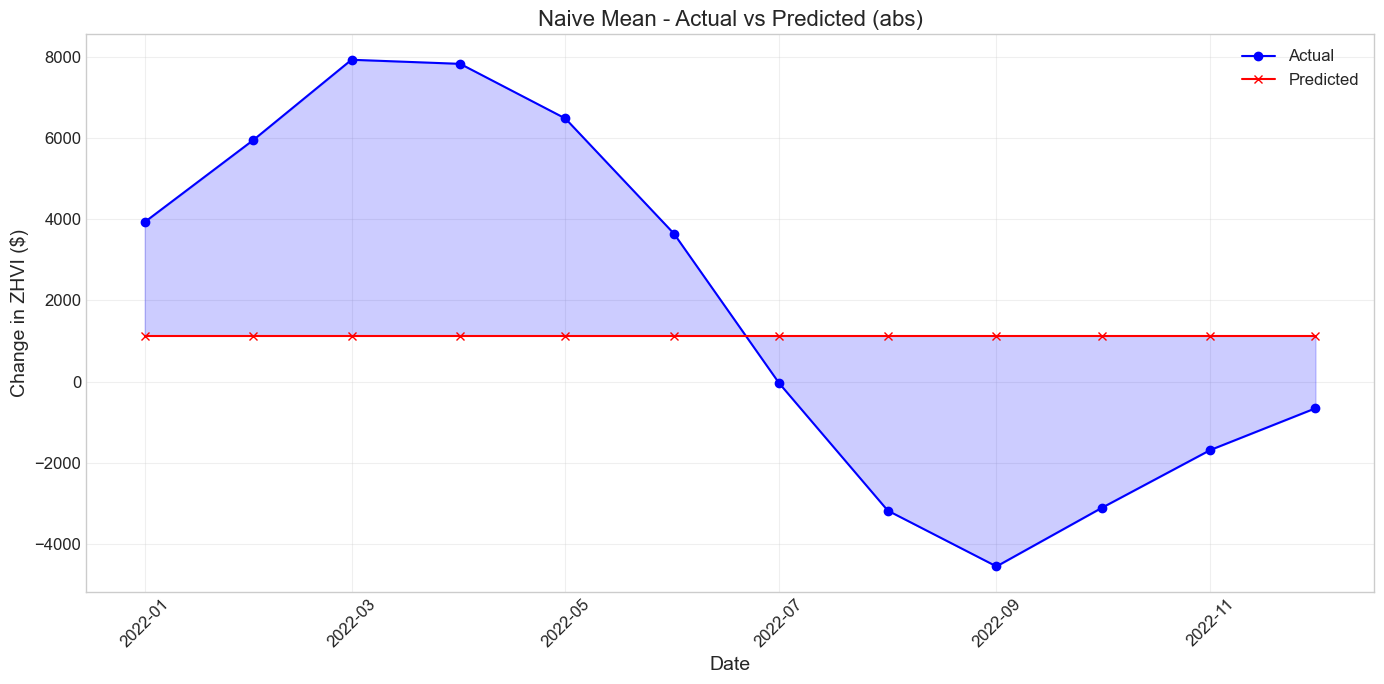

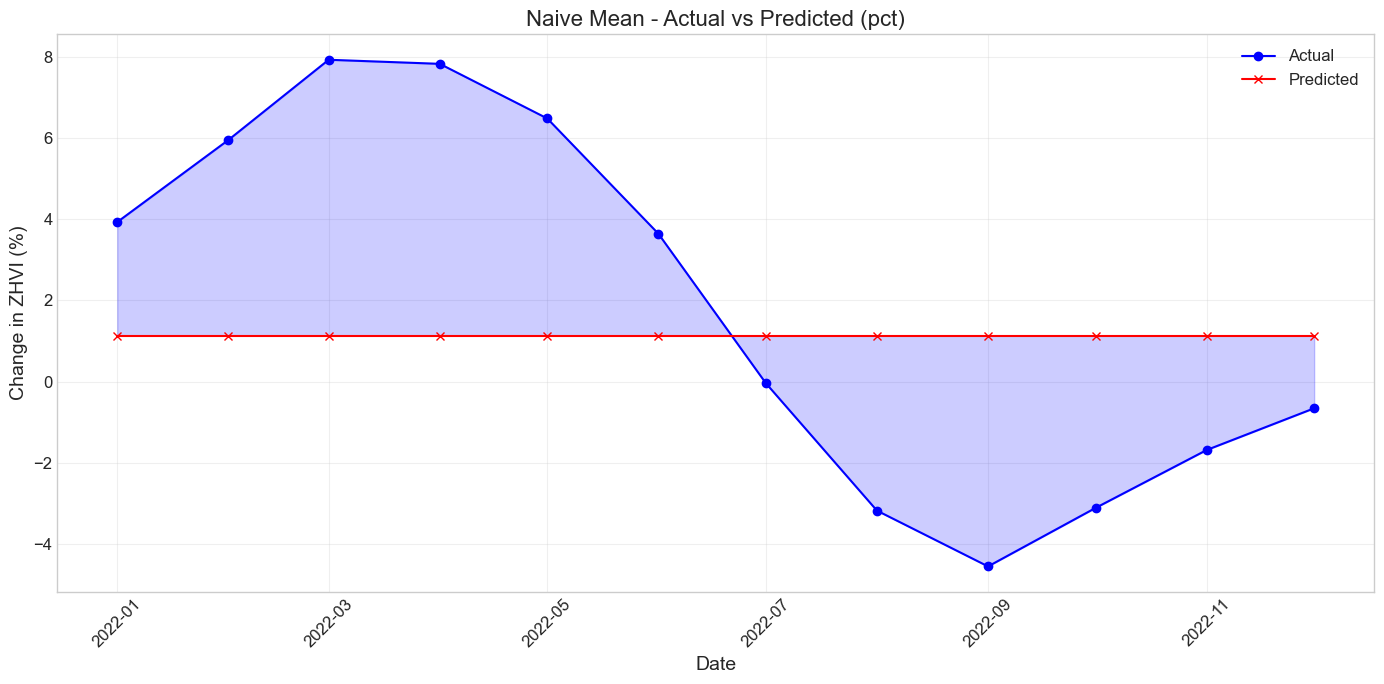

{'Mean Error': np.float64(-0.7443022790446318),
 'Std Dev Error': np.float64(4.39724126903695),
 'Max Overprediction': np.float64(5.690276029288661),
 'Max Underprediction': np.float64(-6.798065170711304)}

In [19]:
def naive_forecast(y_train, y_test, method='previous'):
    """
    Generate naive forecasts using different methods:
    - 'previous': use the last value from training set for all predictions
    - 'mean': use the mean of the training set for all predictions
    - 'seasonal': use the value from the same month in the previous year
    """
    if method == 'previous':
        # Use the last known value for all predictions
        forecast = np.repeat(y_train.iloc[-1], len(y_test))
    elif method == 'mean':
        # Use the mean of the training set for all predictions
        forecast = np.repeat(y_train.mean(), len(y_test))
    elif method == 'seasonal':
        # Use values from 12 months ago (requires enough history)
        if len(y_train) >= 12:
            # Get the last 12 values of training to use for test predictions
            seasonal_values = y_train.iloc[-12:].values
            # If test set is longer than 12 months, repeat the pattern
            forecast = np.tile(seasonal_values, (len(y_test) // 12) + 1)[:len(y_test)]
        else:
            forecast = np.repeat(y_train.mean(), len(y_test))
    
    return forecast

# Create baseline forecasts for absolute changes
y_pred_baseline_prev_abs = naive_forecast(y_train_abs, y_test_abs, 'previous')
y_pred_baseline_mean_abs = naive_forecast(y_train_abs, y_test_abs, 'mean')
y_pred_baseline_seasonal_abs = naive_forecast(y_train_abs, y_test_abs, 'seasonal')

# Create baseline forecasts for percentage changes
y_pred_baseline_prev_pct = naive_forecast(y_train_pct, y_test_pct, 'previous')
y_pred_baseline_mean_pct = naive_forecast(y_train_pct, y_test_pct, 'mean')
y_pred_baseline_seasonal_pct = naive_forecast(y_train_pct, y_test_pct, 'seasonal')

# Evaluate baseline models for absolute changes
baseline_results_abs = []
baseline_results_abs.append(evaluate_model(y_test_abs, y_pred_baseline_prev_abs, 'Naive Previous', 'abs'))
baseline_results_abs.append(evaluate_model(y_test_abs, y_pred_baseline_mean_abs, 'Naive Mean', 'abs'))
baseline_results_abs.append(evaluate_model(y_test_abs, y_pred_baseline_seasonal_abs, 'Naive Seasonal', 'abs'))

# Evaluate baseline models for percentage changes
baseline_results_pct = []
baseline_results_pct.append(evaluate_model(y_test_pct, y_pred_baseline_prev_pct, 'Naive Previous', 'pct'))
baseline_results_pct.append(evaluate_model(y_test_pct, y_pred_baseline_mean_pct, 'Naive Mean', 'pct'))
baseline_results_pct.append(evaluate_model(y_test_pct, y_pred_baseline_seasonal_pct, 'Naive Seasonal', 'pct'))

# Display baseline results
print("\nBaseline Model Results (Absolute Changes):")
display(pd.DataFrame(baseline_results_abs))

print("\nBaseline Model Results (Percentage Changes):")
display(pd.DataFrame(baseline_results_pct))

# Plot the best baseline model for each target type
best_baseline_abs_idx = np.argmax([result['R²'] for result in baseline_results_abs]) 
best_baseline_pct_idx = np.argmax([result['R²'] for result in baseline_results_pct])

# Get predictions from best baseline models
best_baseline_pred_abs = [y_pred_baseline_prev_abs, y_pred_baseline_mean_abs, y_pred_baseline_seasonal_abs][best_baseline_abs_idx]
best_baseline_pred_pct = [y_pred_baseline_prev_pct, y_pred_baseline_mean_pct, y_pred_baseline_seasonal_pct][best_baseline_pct_idx]

# Plot best baselines
best_baseline_name_abs = baseline_results_abs[best_baseline_abs_idx]['Model']
best_baseline_name_pct = baseline_results_pct[best_baseline_pct_idx]['Model']

plot_predictions(y_test_abs, best_baseline_pred_abs, df_test.index, best_baseline_name_abs, 'abs')
plot_predictions(y_test_pct, best_baseline_pred_pct, df_test.index, best_baseline_name_pct, 'pct')


## 4. ARIMA Model - Simplified Approach
Since the dataset is already seasonally adjusted and we've encountered fitting issues, we'll use a simpler approach with one carefully selected ARIMA model:


Trying ARIMA models for absolute changes:
Failed to fit ARIMA(1,1,1) model: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).
Failed to fit ARIMA(1,0,1) model: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).
Failed to fit ARIMA(0,1,1) model: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).

Trying ARIMA models for percentage changes:
Successfully fit ARIMA(1,1,1) model
Successfully fit ARIMA(1,0,1) model
Successfully fit ARIMA(0,1,1) model

ARIMA Model Results (Percentage Changes):


,Model,MAE,RMSE,R²,MAPE
0,"ARIMA(1,1,1)",4.52,5.45,-0.53,NaN
1,"ARIMA(1,0,1)",4.28,5.14,-0.36,NaN
2,"ARIMA(0,1,1)",4.62,5.63,-0.64,NaN


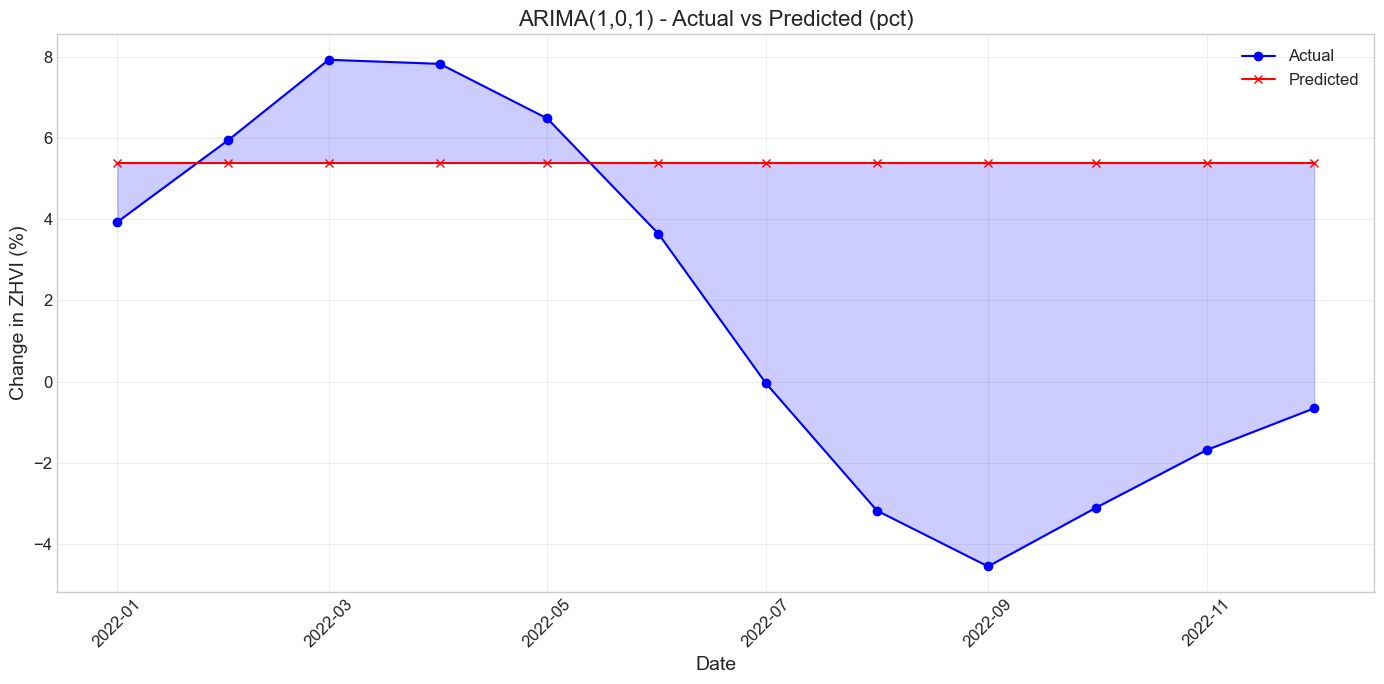

In [20]:
def fit_simple_arima(train, test, target_col, order=(1,1,1)):
    """
    Fit a single ARIMA model with specified order
    
    Parameters:
    - train, test: train and test datasets
    - target_col: column name of the target variable
    - order: ARIMA order parameters (p,d,q)
    
    Returns:
    - Evaluation metrics
    - Predictions
    """
    # Extract data
    y_train = train[target_col]
    y_test = test[target_col]
    
    # Define model name
    p, d, q = order
    model_name = f"ARIMA({p},{d},{q})"
    
    # Fit model with try/except to handle errors
    try:
        # Create and fit ARIMA model
        model = ARIMA(y_train, order=order)
        fitted_model = model.fit()
        
        # Make predictions
        y_pred = fitted_model.forecast(steps=len(y_test))
        
        # Evaluate model
        target_type = 'pct' if 'pct' in target_col else 'abs'
        metrics = evaluate_model(y_test, y_pred, model_name, target_type)
        
        print(f"Successfully fit {model_name} model")
        return metrics, y_pred, True
    
    except Exception as e:
        print(f"Failed to fit {model_name} model: {str(e)}")
        # Return dummy metrics and predictions
        target_type = 'pct' if 'pct' in target_col else 'abs'
        dummy_metrics = {
            'Model': model_name,
            'MAE': np.nan,
            'RMSE': np.nan,
            'R²': -np.inf,
            'MAPE': np.nan
        }
        return dummy_metrics, np.full(len(y_test), np.nan), False

# Try a few simple ARIMA specifications
arima_orders = [(1,1,1), (1,0,1), (0,1,1)]

# For absolute changes
print("\nTrying ARIMA models for absolute changes:")
arima_results_abs = []
arima_success_abs = False

for order in arima_orders:
    metrics, predictions, success = fit_simple_arima(df_train, df_test, target_abs, order)
    if success:
        arima_results_abs.append(metrics)
        arima_success_abs = True
        arima_pred_abs = predictions
        arima_model_abs = metrics['Model']

# For percentage changes
print("\nTrying ARIMA models for percentage changes:")
arima_results_pct = []
arima_success_pct = False

for order in arima_orders:
    metrics, predictions, success = fit_simple_arima(df_train, df_test, target_pct, order)
    if success:
        arima_results_pct.append(metrics)
        arima_success_pct = True
        arima_pred_pct = predictions
        arima_model_pct = metrics['Model']

# Display results if successful
if arima_success_abs:
    print("\nARIMA Model Results (Absolute Changes):")
    arima_df_abs = pd.DataFrame(arima_results_abs)
    display(arima_df_abs)
    
    # Plot best ARIMA model for absolute changes
    best_arima_idx_abs = np.argmax(arima_df_abs['R²']) if len(arima_df_abs) > 0 else 0
    best_arima_model_abs = arima_df_abs.iloc[best_arima_idx_abs]['Model']
    plot_predictions(y_test_abs, arima_pred_abs, df_test.index, best_arima_model_abs, 'abs')

if arima_success_pct:
    print("\nARIMA Model Results (Percentage Changes):")
    arima_df_pct = pd.DataFrame(arima_results_pct)
    display(arima_df_pct)
    
    # Plot best ARIMA model for percentage changes
    best_arima_idx_pct = np.argmax(arima_df_pct['R²']) if len(arima_df_pct) > 0 else 0
    best_arima_model_pct = arima_df_pct.iloc[best_arima_idx_pct]['Model']
    plot_predictions(y_test_pct, arima_pred_pct, df_test.index, best_arima_model_pct, 'pct')
else:
    print("\nNo successful ARIMA models for percentage changes.")


## 5. Machine Learning Models

### 5.1 Linear Models


Training linear models for absolute changes...

Training linear models for percentage changes...

Linear Model Results (Absolute Changes):


,Model,MAE,RMSE,R²,MAPE,Val_RMSE
0,Linear Regression,3051.78,3472.41,0.38,83.73,1.03
1,Ridge Regression (α=1.0),3074.35,3488.96,0.37,82.49,1.04
2,Ridge Regression (α=10.0),3202.45,3619.10,0.32,79.89,1.17
3,Ridge Regression (α=100.0),3586.70,4019.68,0.16,91.11,1.30
5,"ElasticNet (α=1.0, l1_ratio=0.5)",4084.88,4459.79,-0.03,119.11,1.32
4,Lasso Regression (α=0.1),3878.94,4323.79,0.03,103.66,1.36



Best linear model for absolute changes: Linear Regression


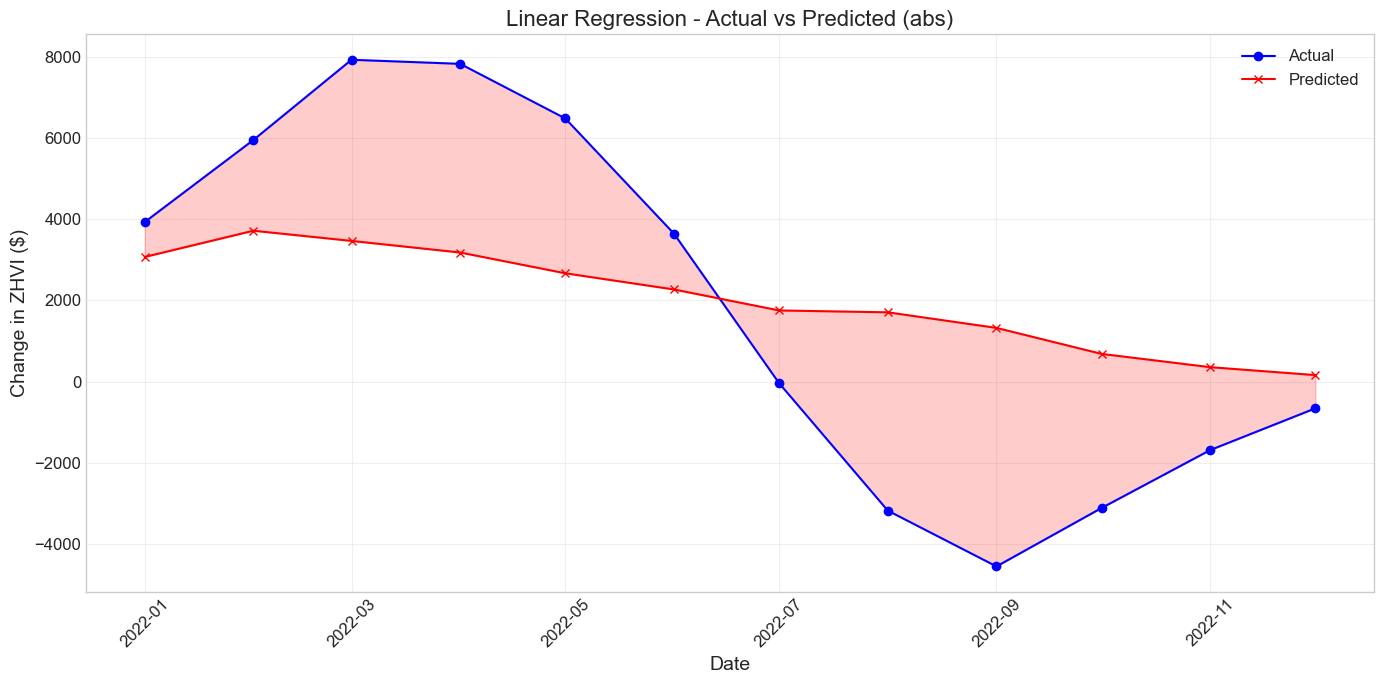


Feature Importance (Absolute Changes):


,Feature,Importance,Direction
2,CPI,2.29,-1
1,Median_Household_Income,2.09,1
5,Unemployment_Rate_lag10,0.43,1
0,Interest_Rate,0.21,-1
3,real_mortgage_rate,0.14,-1
4,Poverty_Rate_lag13,0.10,1


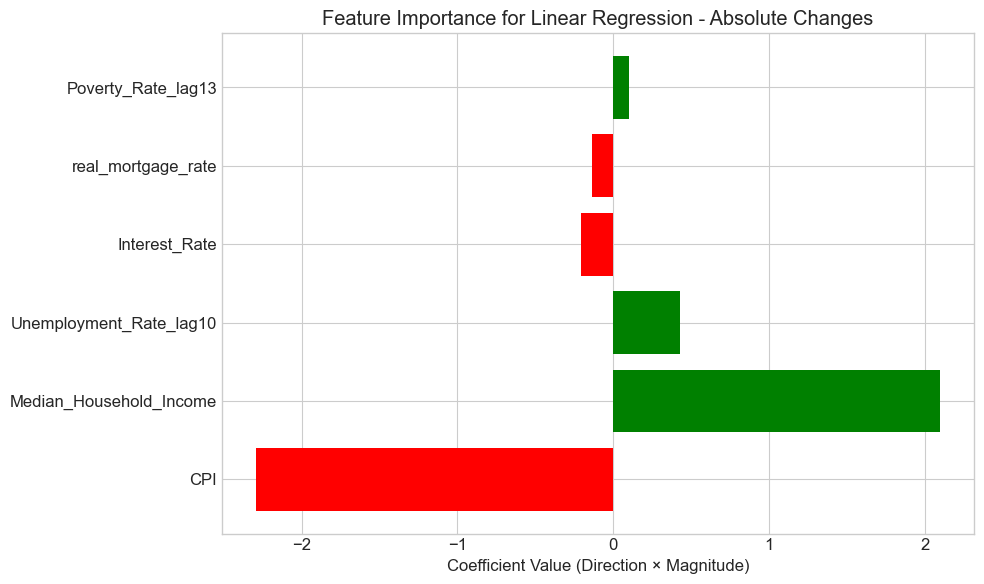


Linear Model Results (Percentage Changes):


,Model,MAE,RMSE,R²,MAPE,Val_RMSE
0,Linear Regression,3.05,3.47,0.38,428.48,1.03
1,Ridge Regression (α=1.0),3.07,3.49,0.37,420.45,1.04
2,Ridge Regression (α=10.0),3.20,3.62,0.32,386.88,1.17
3,Ridge Regression (α=100.0),3.59,4.02,0.16,325.53,1.30
5,"ElasticNet (α=1.0, l1_ratio=0.5)",4.08,4.46,-0.03,339.54,1.32
4,Lasso Regression (α=0.1),3.88,4.32,0.03,285.05,1.36



Best linear model for percentage changes: Linear Regression


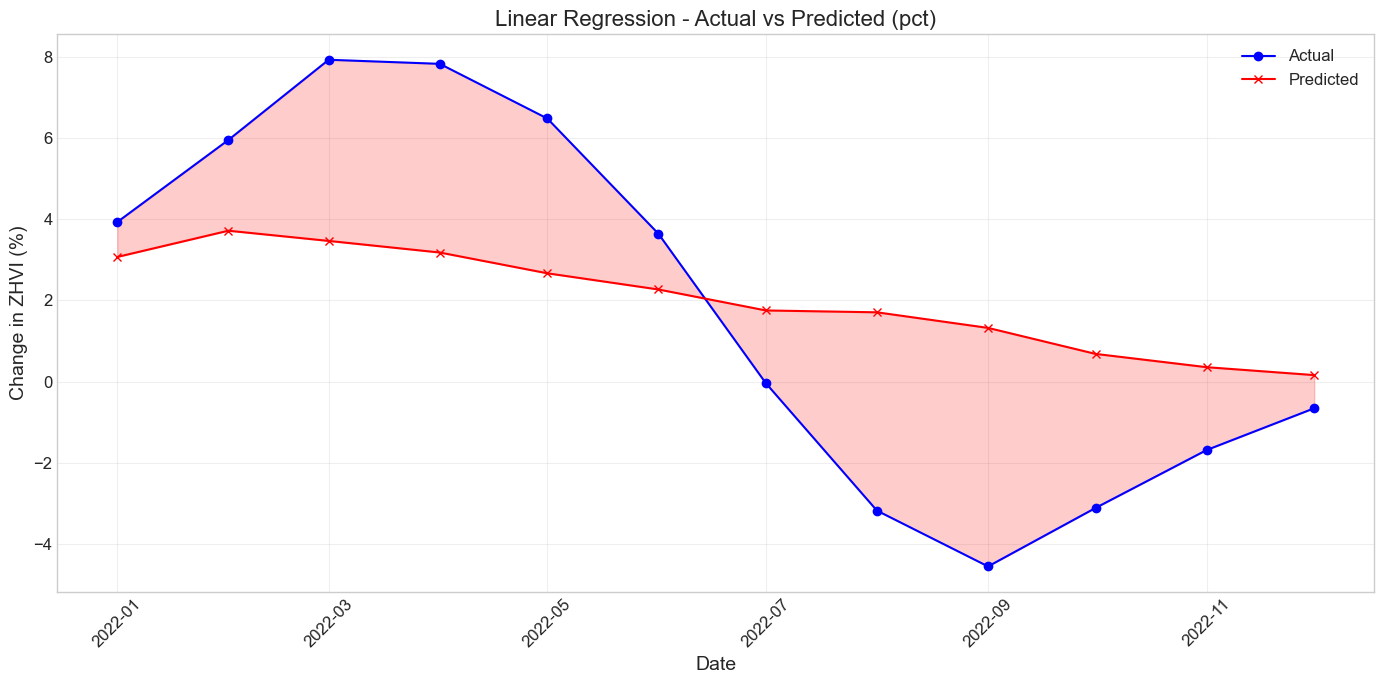


Feature Importance (Percentage Changes):


,Feature,Importance,Direction
2,CPI,2.29,-1
1,Median_Household_Income,2.09,1
5,Unemployment_Rate_lag10,0.43,1
0,Interest_Rate,0.21,-1
3,real_mortgage_rate,0.14,-1
4,Poverty_Rate_lag13,0.10,1


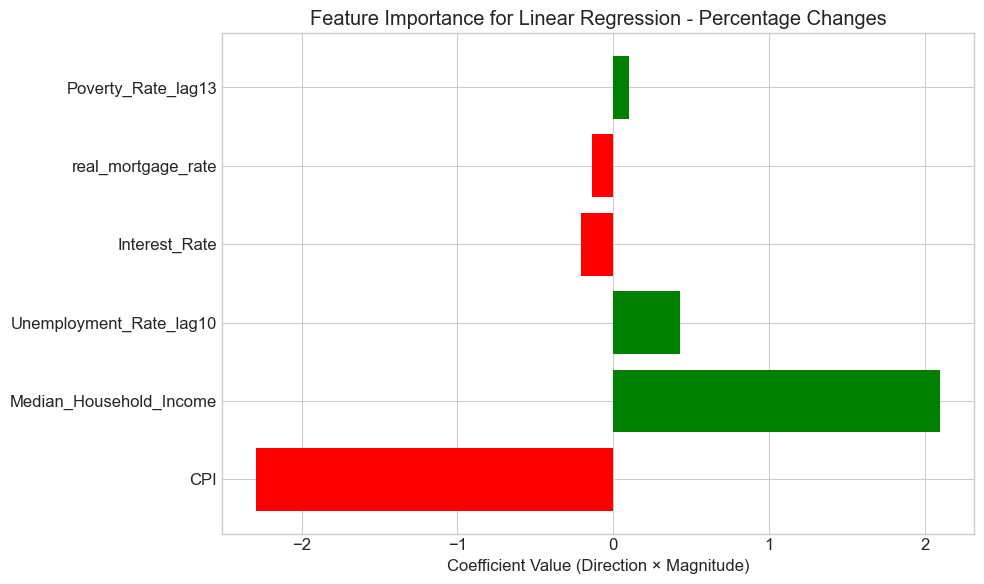

In [21]:
def train_evaluate_ml_model(model, X_train, y_train, X_val, y_val, X_test, y_test, model_name, target_type):
    """Train and evaluate a machine learning model"""
    # Train model
    model.fit(X_train, y_train)
    
    # Make predictions for validation and test sets
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    
    # Evaluate on validation set
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    
    # Evaluate on test set
    test_metrics = evaluate_model(y_test, y_test_pred, model_name, target_type)
    
    # Add validation RMSE
    test_metrics['Val_RMSE'] = val_rmse
    
    return test_metrics, y_test_pred, model

# Define linear models for both absolute and percentage changes
linear_models_abs = [
    (LinearRegression(), "Linear Regression"),
    (Ridge(alpha=1.0), "Ridge Regression (α=1.0)"),
    (Ridge(alpha=10.0), "Ridge Regression (α=10.0)"),
    (Ridge(alpha=100.0), "Ridge Regression (α=100.0)"),
    (Lasso(alpha=0.1), "Lasso Regression (α=0.1)"),
    (ElasticNet(alpha=1.0, l1_ratio=0.5), "ElasticNet (α=1.0, l1_ratio=0.5)")
]

linear_models_pct = [
    (LinearRegression(), "Linear Regression"),
    (Ridge(alpha=1.0), "Ridge Regression (α=1.0)"),
    (Ridge(alpha=10.0), "Ridge Regression (α=10.0)"),
    (Ridge(alpha=100.0), "Ridge Regression (α=100.0)"),
    (Lasso(alpha=0.1), "Lasso Regression (α=0.1)"),
    (ElasticNet(alpha=1.0, l1_ratio=0.5), "ElasticNet (α=1.0, l1_ratio=0.5)")
]

# Train and evaluate models for absolute changes
print("\nTraining linear models for absolute changes...")
linear_results_abs = []
best_val_rmse_linear_abs = np.inf
best_linear_pred_abs = None
best_linear_model_abs = None
best_linear_model_obj_abs = None

for model, name in linear_models_abs:
    metrics, predictions, trained_model = train_evaluate_ml_model(
        model, X_train_scaled, y_train_abs_scaled, 
        X_val_scaled, y_val_abs_scaled,
        X_test_scaled, y_test_abs_scaled,
        name, 'abs'
    )
    
    # Convert predictions back to original scale for plotting and final metrics
    predictions_original = scaler_y_abs.inverse_transform(predictions.reshape(-1, 1)).ravel()
    
    # Recalculate metrics on original scale
    metrics_original = evaluate_model(y_test_abs, predictions_original, name, 'abs')
    metrics_original['Val_RMSE'] = metrics['Val_RMSE']  # Keep the scaled validation RMSE for model selection
    
    linear_results_abs.append(metrics_original)
    
    # Update best model
    if metrics['Val_RMSE'] < best_val_rmse_linear_abs:
        best_val_rmse_linear_abs = metrics['Val_RMSE']
        best_linear_pred_abs = predictions_original
        best_linear_model_abs = name
        best_linear_model_obj_abs = trained_model

# Train and evaluate models for percentage changes
print("\nTraining linear models for percentage changes...")
linear_results_pct = []
best_val_rmse_linear_pct = np.inf
best_linear_pred_pct = None
best_linear_model_pct = None
best_linear_model_obj_pct = None

for model, name in linear_models_pct:
    metrics, predictions, trained_model = train_evaluate_ml_model(
        model, X_train_scaled, y_train_pct_scaled, 
        X_val_scaled, y_val_pct_scaled,
        X_test_scaled, y_test_pct_scaled,
        name, 'pct'
    )
    
    # Convert predictions back to original scale
    predictions_original = scaler_y_pct.inverse_transform(predictions.reshape(-1, 1)).ravel()
    
    # Recalculate metrics on original scale
    metrics_original = evaluate_model(y_test_pct, predictions_original, name, 'pct')
    metrics_original['Val_RMSE'] = metrics['Val_RMSE']
    
    linear_results_pct.append(metrics_original)
    
    # Update best model
    if metrics['Val_RMSE'] < best_val_rmse_linear_pct:
        best_val_rmse_linear_pct = metrics['Val_RMSE']
        best_linear_pred_pct = predictions_original
        best_linear_model_pct = name
        best_linear_model_obj_pct = trained_model

# Display results
print("\nLinear Model Results (Absolute Changes):")
linear_df_abs = pd.DataFrame(linear_results_abs).sort_values('Val_RMSE')
display(linear_df_abs)

print(f"\nBest linear model for absolute changes: {best_linear_model_abs}")
plot_predictions(y_test_abs, best_linear_pred_abs, df_test.index, best_linear_model_abs, 'abs')

# Feature importance for the best linear model (with safeguards for NaN values)
if best_linear_model_obj_abs is not None:
    coef = best_linear_model_obj_abs.coef_
    
    # Create feature importance DataFrame
    feature_importance_abs = pd.DataFrame({
        'Feature': features,
        'Importance': np.abs(coef),
        'Direction': np.sign(coef)
    }).sort_values('Importance', ascending=False)
    
    # Handle any NaN values in the Direction column
    feature_importance_abs['Direction'] = feature_importance_abs['Direction'].fillna(0).astype(int)
    
    print("\nFeature Importance (Absolute Changes):")
    display(feature_importance_abs)
    
    # Create a color map that handles all possible Direction values
    color_map = {1: 'green', -1: 'red', 0: 'gray'}
    
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance_abs['Feature'], 
             feature_importance_abs['Importance'] * feature_importance_abs['Direction'],
             color=feature_importance_abs['Direction'].map(color_map))
    plt.title(f'Feature Importance for {best_linear_model_abs} - Absolute Changes')
    plt.xlabel('Coefficient Value (Direction × Magnitude)')
    plt.tight_layout()
    plt.savefig(f"outputs/models/feature_importance_abs_{best_linear_model_abs.replace(' ', '_').lower()}.png", 
              dpi=300, bbox_inches='tight')
    plt.show()

print("\nLinear Model Results (Percentage Changes):")
linear_df_pct = pd.DataFrame(linear_results_pct).sort_values('Val_RMSE')
display(linear_df_pct)

print(f"\nBest linear model for percentage changes: {best_linear_model_pct}")
plot_predictions(y_test_pct, best_linear_pred_pct, df_test.index, best_linear_model_pct, 'pct')

# Feature importance for the best linear model (with safeguards for NaN values)
if best_linear_model_obj_pct is not None:
    coef = best_linear_model_obj_pct.coef_
    
    # Create feature importance DataFrame
    feature_importance_pct = pd.DataFrame({
        'Feature': features,
        'Importance': np.abs(coef),
        'Direction': np.sign(coef)
    }).sort_values('Importance', ascending=False)
    
    # Handle any NaN values in the Direction column
    feature_importance_pct['Direction'] = feature_importance_pct['Direction'].fillna(0).astype(int)
    
    print("\nFeature Importance (Percentage Changes):")
    display(feature_importance_pct)
    
    # Create a color map that handles all possible Direction values
    color_map = {1: 'green', -1: 'red', 0: 'gray'}
    
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance_pct['Feature'], 
             feature_importance_pct['Importance'] * feature_importance_pct['Direction'],
             color=feature_importance_pct['Direction'].map(color_map))
    plt.title(f'Feature Importance for {best_linear_model_pct} - Percentage Changes')
    plt.xlabel('Coefficient Value (Direction × Magnitude)')
    plt.tight_layout()
    plt.savefig(f"outputs/models/feature_importance_pct_{best_linear_model_pct.replace(' ', '_').lower()}.png", 
              dpi=300, bbox_inches='tight')
    plt.show()


## 6. Nonlinear Models


Training nonlinear models for absolute changes...

Training nonlinear models for percentage changes...

Nonlinear Model Results (Absolute Changes):


,Model,MAE,RMSE,R²,MAPE,Val_RMSE
1,Gradient Boosting,4426.98,5230.48,-0.41,191.88,1.13
0,Random Forest,4628.95,5637.11,-0.64,207.32,1.22
2,Support Vector Regression,4334.21,4876.46,-0.23,116.76,1.33
3,Neural Network,4476.80,5553.75,-0.60,159.34,2.02



Best nonlinear model for absolute changes: Gradient Boosting


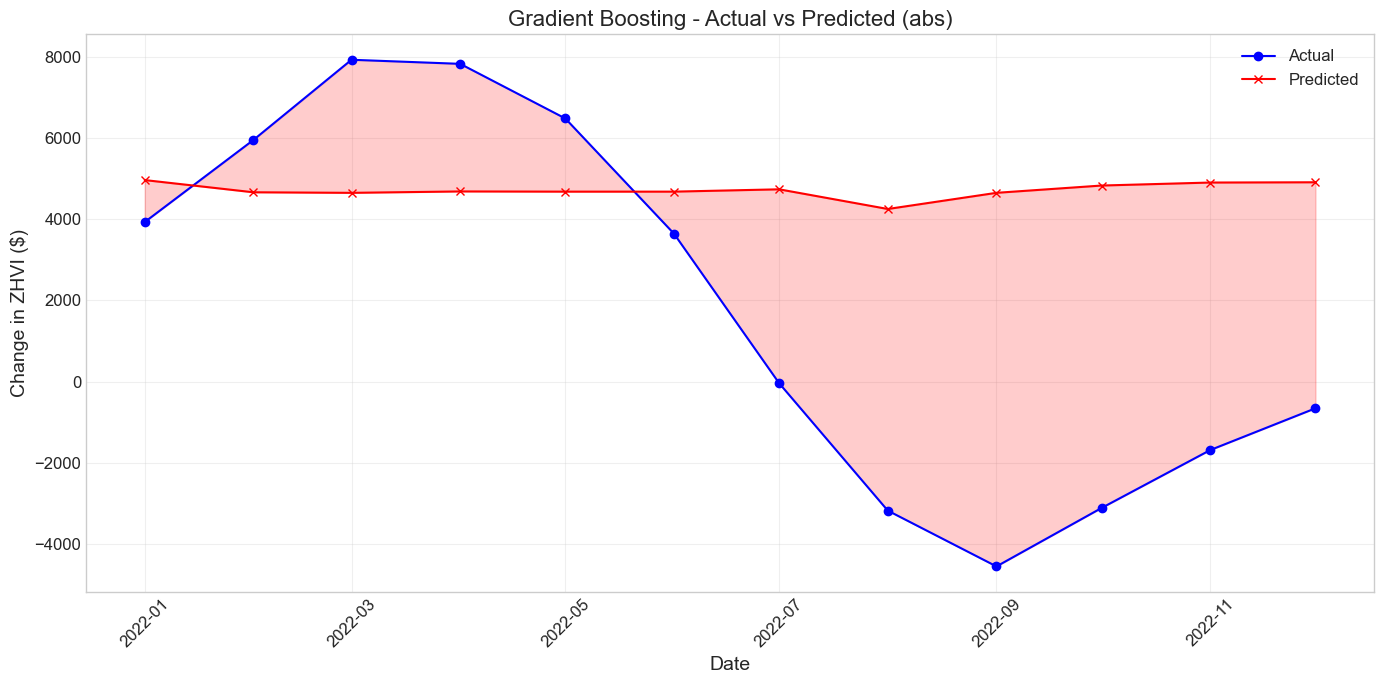


Feature Importance for Gradient Boosting - abs Changes:


,Feature,Importance
1,Median_Household_Income,0.57
2,CPI,0.22
5,Unemployment_Rate_lag10,0.15
4,Poverty_Rate_lag13,0.03
3,real_mortgage_rate,0.02
0,Interest_Rate,0.01


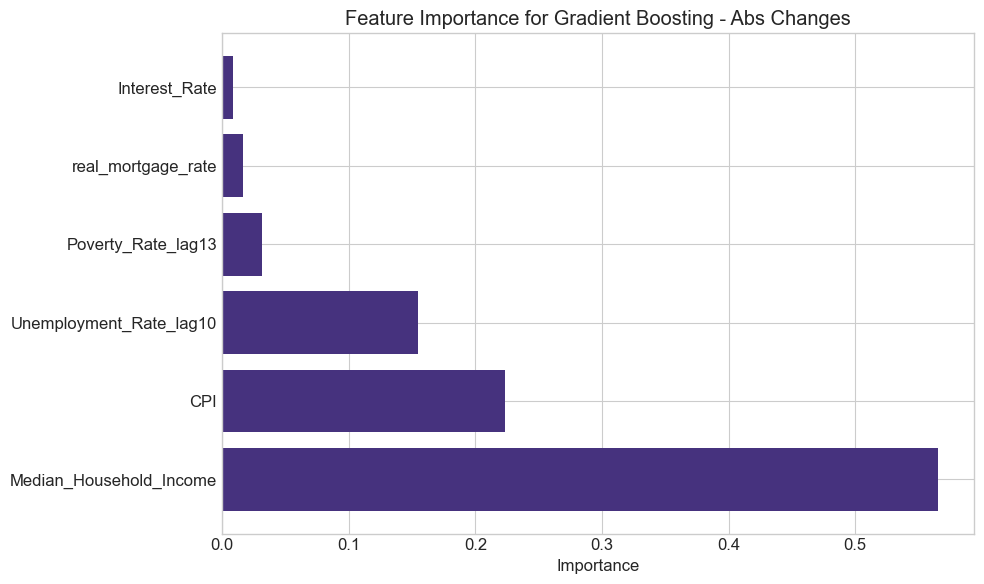


Nonlinear Model Results (Percentage Changes):


,Model,MAE,RMSE,R²,MAPE,Val_RMSE
1,Gradient Boosting,4.44,5.24,-0.42,1088.50,1.10
0,Random Forest,4.64,5.65,-0.65,1260.73,1.22
2,Support Vector Regression,4.33,4.88,-0.23,192.42,1.33
3,Neural Network,4.48,5.55,-0.60,1574.97,2.02



Best nonlinear model for percentage changes: Gradient Boosting


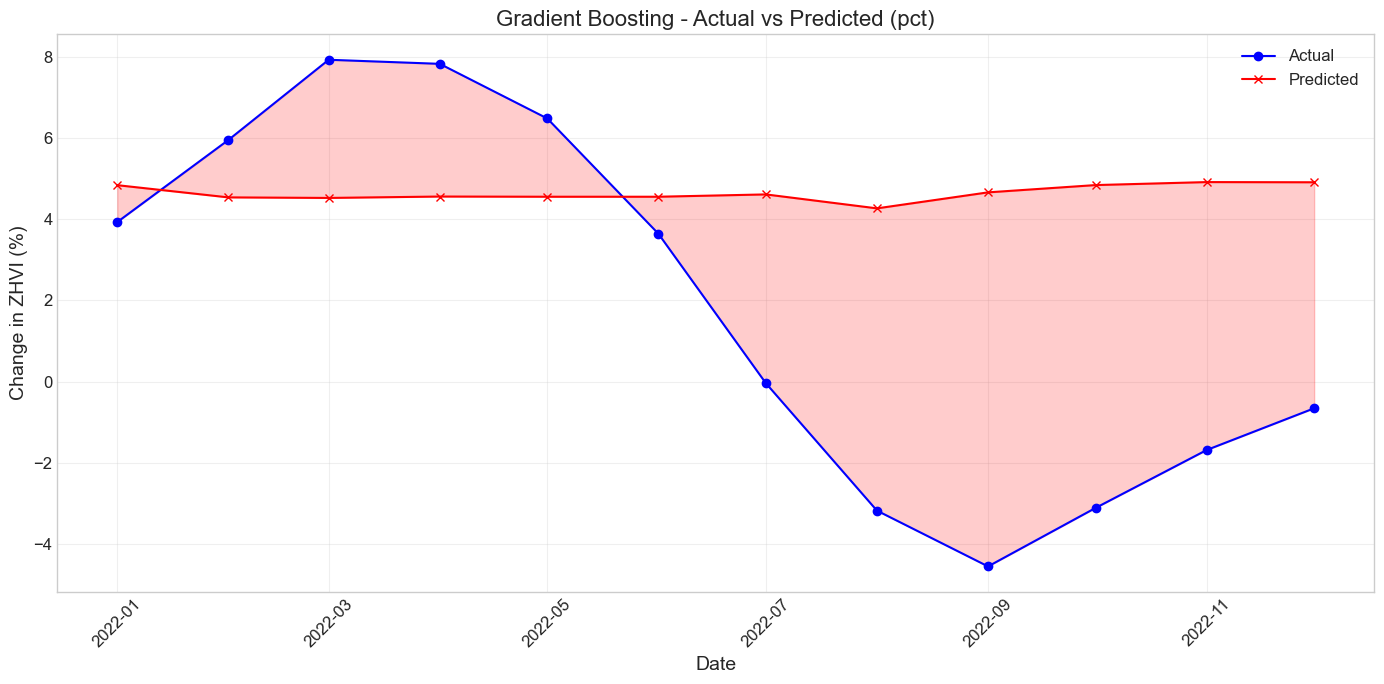


Feature Importance for Gradient Boosting - pct Changes:


,Feature,Importance
1,Median_Household_Income,0.51
2,CPI,0.28
5,Unemployment_Rate_lag10,0.16
4,Poverty_Rate_lag13,0.03
3,real_mortgage_rate,0.02
0,Interest_Rate,0.01


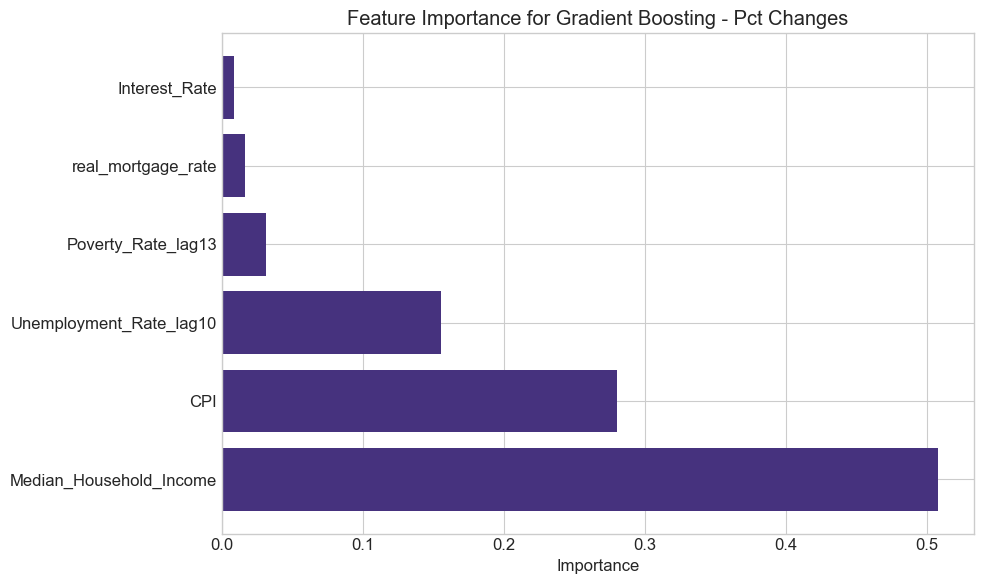

In [22]:
# Define nonlinear models
nonlinear_models_abs = [
    (RandomForestRegressor(n_estimators=100, random_state=42), "Random Forest"),
    (GradientBoostingRegressor(n_estimators=100, random_state=42), "Gradient Boosting"),
    (SVR(kernel='rbf', gamma='scale'), "Support Vector Regression"),
    (MLPRegressor(hidden_layer_sizes=(50, 25), max_iter=1000, random_state=42), "Neural Network")
]

nonlinear_models_pct = [
    (RandomForestRegressor(n_estimators=100, random_state=42), "Random Forest"),
    (GradientBoostingRegressor(n_estimators=100, random_state=42), "Gradient Boosting"),
    (SVR(kernel='rbf', gamma='scale'), "Support Vector Regression"),
    (MLPRegressor(hidden_layer_sizes=(50, 25), max_iter=1000, random_state=42), "Neural Network")
]

# Function for feature importance for tree-based models
def plot_tree_feature_importance(model, features, model_name, target_type):
    """Plot feature importance for tree-based models with safety checks for NaN values"""
    if hasattr(model, 'feature_importances_'):
        # Get feature importances
        importances = model.feature_importances_
        
        # Create DataFrame for feature importance
        feature_importance = pd.DataFrame({
            'Feature': features,
            'Importance': importances
        }).sort_values('Importance', ascending=False)
        
        # Handle any NaN values
        feature_importance['Importance'] = feature_importance['Importance'].fillna(0)
        
        print(f"\nFeature Importance for {model_name} - {target_type} Changes:")
        display(feature_importance)
        
        plt.figure(figsize=(10, 6))
        plt.barh(feature_importance['Feature'], feature_importance['Importance'])
        plt.title(f'Feature Importance for {model_name} - {target_type.capitalize()} Changes')
        plt.xlabel('Importance')
        plt.tight_layout()
        plt.savefig(f"outputs/models/feature_importance_{target_type}_{model_name.replace(' ', '_').lower()}.png", 
                  dpi=300, bbox_inches='tight')
        plt.show()
        
        return feature_importance
    
    return None

# Train and evaluate nonlinear models for absolute changes
print("\nTraining nonlinear models for absolute changes...")
nonlinear_results_abs = []
best_val_rmse_nonlinear_abs = np.inf
best_nonlinear_pred_abs = None
best_nonlinear_model_abs = None
best_nonlinear_model_obj_abs = None

for model, name in nonlinear_models_abs:
    try:
        metrics, predictions, trained_model = train_evaluate_ml_model(
            model, X_train_scaled, y_train_abs_scaled, 
            X_val_scaled, y_val_abs_scaled,
            X_test_scaled, y_test_abs_scaled,
            name, 'abs'
        )
        
        # Convert predictions back to original scale
        predictions_original = scaler_y_abs.inverse_transform(predictions.reshape(-1, 1)).ravel()
        
        # Recalculate metrics on original scale
        metrics_original = evaluate_model(y_test_abs, predictions_original, name, 'abs')
        metrics_original['Val_RMSE'] = metrics['Val_RMSE']
        
        nonlinear_results_abs.append(metrics_original)
        
        # Update best model
        if metrics['Val_RMSE'] < best_val_rmse_nonlinear_abs:
            best_val_rmse_nonlinear_abs = metrics['Val_RMSE']
            best_nonlinear_pred_abs = predictions_original
            best_nonlinear_model_abs = name
            best_nonlinear_model_obj_abs = trained_model
            
    except Exception as e:
        print(f"Error training {name} for absolute changes: {str(e)}")

# Train and evaluate nonlinear models for percentage changes
print("\nTraining nonlinear models for percentage changes...")
nonlinear_results_pct = []
best_val_rmse_nonlinear_pct = np.inf
best_nonlinear_pred_pct = None
best_nonlinear_model_pct = None
best_nonlinear_model_obj_pct = None

for model, name in nonlinear_models_pct:
    try:
        metrics, predictions, trained_model = train_evaluate_ml_model(
            model, X_train_scaled, y_train_pct_scaled, 
            X_val_scaled, y_val_pct_scaled,
            X_test_scaled, y_test_pct_scaled,
            name, 'pct'
        )
        
        # Convert predictions back to original scale
        predictions_original = scaler_y_pct.inverse_transform(predictions.reshape(-1, 1)).ravel()
        
        # Recalculate metrics on original scale
        metrics_original = evaluate_model(y_test_pct, predictions_original, name, 'pct')
        metrics_original['Val_RMSE'] = metrics['Val_RMSE']
        
        nonlinear_results_pct.append(metrics_original)
        
        # Update best model
        if metrics['Val_RMSE'] < best_val_rmse_nonlinear_pct:
            best_val_rmse_nonlinear_pct = metrics['Val_RMSE']
            best_nonlinear_pred_pct = predictions_original
            best_nonlinear_model_pct = name
            best_nonlinear_model_obj_pct = trained_model
            
    except Exception as e:
        print(f"Error training {name} for percentage changes: {str(e)}")

# Display results if we have any successful models
if nonlinear_results_abs:
    print("\nNonlinear Model Results (Absolute Changes):")
    nonlinear_df_abs = pd.DataFrame(nonlinear_results_abs).sort_values('Val_RMSE')
    display(nonlinear_df_abs)

    print(f"\nBest nonlinear model for absolute changes: {best_nonlinear_model_abs}")
    plot_predictions(y_test_abs, best_nonlinear_pred_abs, df_test.index, best_nonlinear_model_abs, 'abs')

    # Feature importance for best tree-based model
    if best_nonlinear_model_obj_abs is not None:
        plot_tree_feature_importance(best_nonlinear_model_obj_abs, features, best_nonlinear_model_abs, 'abs')

if nonlinear_results_pct:
    print("\nNonlinear Model Results (Percentage Changes):")
    nonlinear_df_pct = pd.DataFrame(nonlinear_results_pct).sort_values('Val_RMSE')
    display(nonlinear_df_pct)

    print(f"\nBest nonlinear model for percentage changes: {best_nonlinear_model_pct}")
    plot_predictions(y_test_pct, best_nonlinear_pred_pct, df_test.index, best_nonlinear_model_pct, 'pct')

    # Feature importance for best tree-based model
    if best_nonlinear_model_obj_pct is not None:
        plot_tree_feature_importance(best_nonlinear_model_obj_pct, features, best_nonlinear_model_pct, 'pct')


## 7. Ensemble Approach


Creating ensemble models for absolute changes...

Ensemble Model Results (Absolute Changes):


,Model,MAE,RMSE,R²,MAPE,Val_RMSE
0,Voting Ensemble,3581.27,4185.64,0.09,133.23,1.02


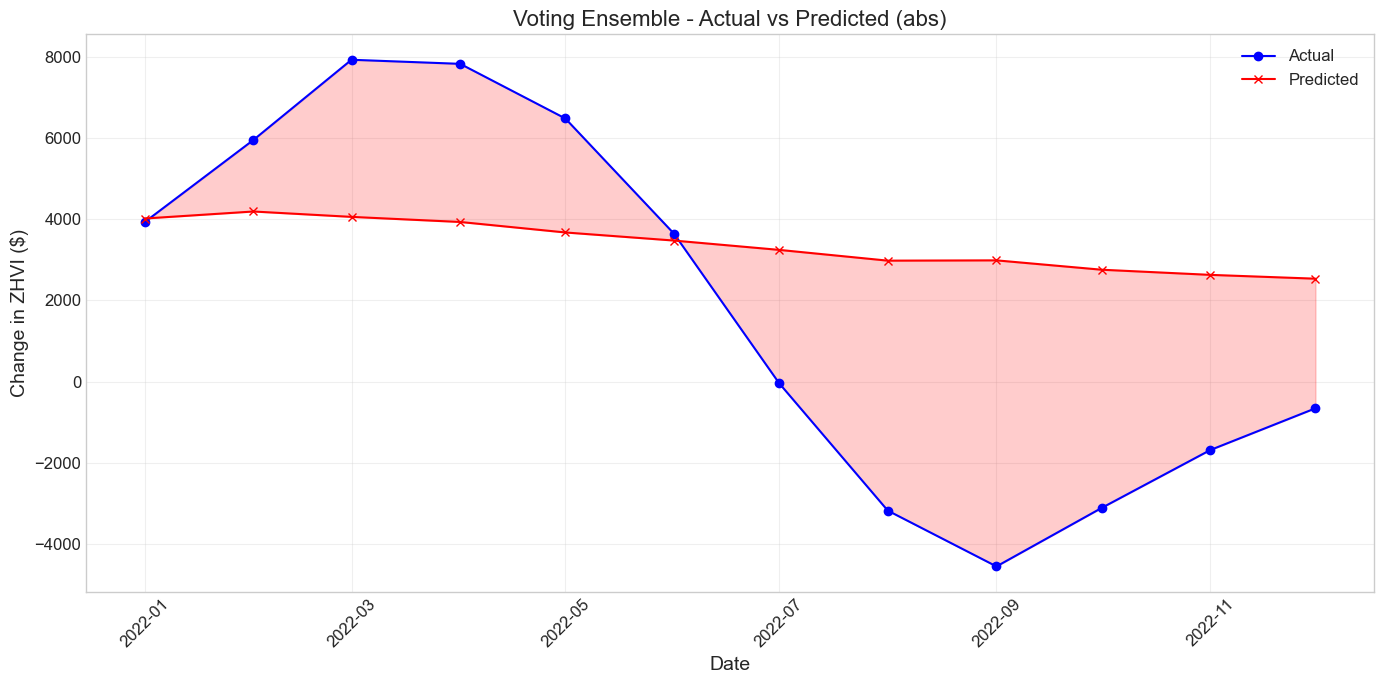


Creating ensemble models for percentage changes...

Ensemble Model Results (Percentage Changes):


,Model,MAE,RMSE,R²,MAPE,Val_RMSE
0,Voting Ensemble,3.60,4.20,0.09,754.58,1.01


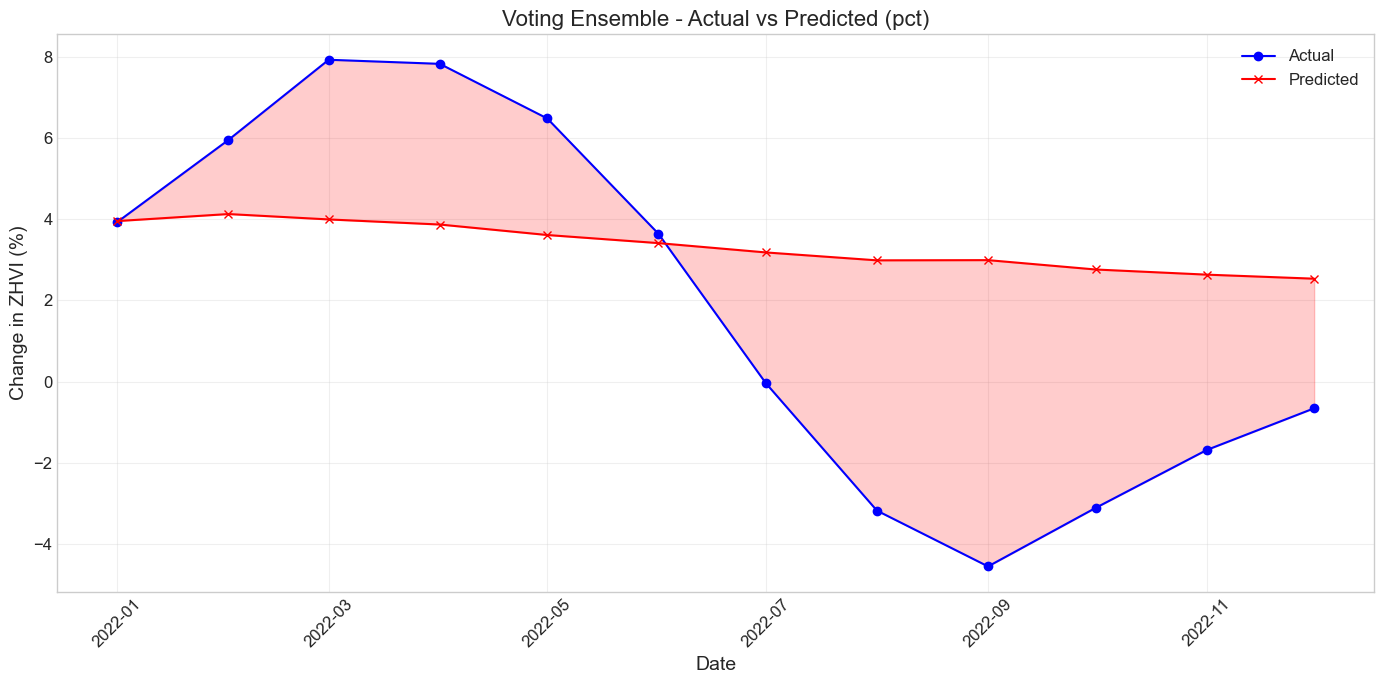

In [23]:
# Create ensemble models from best performers of each category
def create_voting_ensemble(models, weights=None):
    """Create a voting ensemble from a list of models with optional weights"""
    return VotingRegressor(models, weights=weights)

# For absolute changes
print("\nCreating ensemble models for absolute changes...")
# Only include models that were successfully trained
ensemble_models_abs = []
ensemble_weights_abs = []

# Safety check for best models
has_linear_abs = 'best_linear_model_obj_abs' in locals() and best_linear_model_obj_abs is not None
has_nonlinear_abs = 'best_nonlinear_model_obj_abs' in locals() and best_nonlinear_model_obj_abs is not None

if has_linear_abs:
    ensemble_models_abs.append((f'linear_{best_linear_model_abs}', best_linear_model_obj_abs))
    ensemble_weights_abs.append(1)

if has_nonlinear_abs:
    ensemble_models_abs.append((f'nonlinear_{best_nonlinear_model_abs}', best_nonlinear_model_obj_abs))
    ensemble_weights_abs.append(1)

if len(ensemble_models_abs) > 1:
    # Create and train ensemble
    ensemble_model_abs = create_voting_ensemble(
        ensemble_models_abs, 
        weights=ensemble_weights_abs if len(ensemble_weights_abs) > 0 else None
    )
    
    try:
        # Train and evaluate
        ensemble_metrics_abs, ensemble_pred_abs_scaled, _ = train_evaluate_ml_model(
            ensemble_model_abs, X_train_scaled, y_train_abs_scaled, 
            X_val_scaled, y_val_abs_scaled,
            X_test_scaled, y_test_abs_scaled,
            "Voting Ensemble", 'abs'
        )
        
        # Convert predictions back to original scale
        ensemble_pred_abs = scaler_y_abs.inverse_transform(ensemble_pred_abs_scaled.reshape(-1, 1)).ravel()
        
        # Recalculate metrics on original scale
        ensemble_metrics_abs_original = evaluate_model(y_test_abs, ensemble_pred_abs, "Voting Ensemble", 'abs')
        ensemble_metrics_abs_original['Val_RMSE'] = ensemble_metrics_abs['Val_RMSE']
        
        print("\nEnsemble Model Results (Absolute Changes):")
        display(pd.DataFrame([ensemble_metrics_abs_original]))
        plot_predictions(y_test_abs, ensemble_pred_abs, df_test.index, "Voting Ensemble", 'abs')
        
    except Exception as e:
        print(f"Error training ensemble for absolute changes: {str(e)}")

# For percentage changes
print("\nCreating ensemble models for percentage changes...")
# Only include models that were successfully trained
ensemble_models_pct = []
ensemble_weights_pct = []

# Safety check for best models
has_linear_pct = 'best_linear_model_obj_pct' in locals() and best_linear_model_obj_pct is not None
has_nonlinear_pct = 'best_nonlinear_model_obj_pct' in locals() and best_nonlinear_model_obj_pct is not None

if has_linear_pct:
    ensemble_models_pct.append((f'linear_{best_linear_model_pct}', best_linear_model_obj_pct))
    ensemble_weights_pct.append(1)

if has_nonlinear_pct:
    ensemble_models_pct.append((f'nonlinear_{best_nonlinear_model_pct}', best_nonlinear_model_obj_pct))
    ensemble_weights_pct.append(1)

if len(ensemble_models_pct) > 1:
    # Create and train ensemble
    ensemble_model_pct = create_voting_ensemble(
        ensemble_models_pct,
        weights=ensemble_weights_pct if len(ensemble_weights_pct) > 0 else None
    )
    
    try:
        # Train and evaluate
        ensemble_metrics_pct, ensemble_pred_pct_scaled, _ = train_evaluate_ml_model(
            ensemble_model_pct, X_train_scaled, y_train_pct_scaled, 
            X_val_scaled, y_val_pct_scaled,
            X_test_scaled, y_test_pct_scaled,
            "Voting Ensemble", 'pct'
        )
        
        # Convert predictions back to original scale
        ensemble_pred_pct = scaler_y_pct.inverse_transform(ensemble_pred_pct_scaled.reshape(-1, 1)).ravel()
        
        # Recalculate metrics on original scale
        ensemble_metrics_pct_original = evaluate_model(y_test_pct, ensemble_pred_pct, "Voting Ensemble", 'pct')
        ensemble_metrics_pct_original['Val_RMSE'] = ensemble_metrics_pct['Val_RMSE']
        
        print("\nEnsemble Model Results (Percentage Changes):")
        display(pd.DataFrame([ensemble_metrics_pct_original]))
        plot_predictions(y_test_pct, ensemble_pred_pct, df_test.index, "Voting Ensemble", 'pct')
        
    except Exception as e:
        print(f"Error training ensemble for percentage changes: {str(e)}")


## 8. Model Comparison and Selection

In [24]:
# Collect all successful model results
all_results_abs = baseline_results_abs + linear_results_abs
all_results_pct = baseline_results_pct + linear_results_pct

# Add ARIMA results if successful
if 'arima_results_abs' in locals() and arima_results_abs:
    all_results_abs.extend(arima_results_abs)
if 'arima_results_pct' in locals() and arima_results_pct:
    all_results_pct.extend(arima_results_pct)

# Add nonlinear results if successful
if 'nonlinear_results_abs' in locals() and nonlinear_results_abs:
    all_results_abs.extend(nonlinear_results_abs)
if 'nonlinear_results_pct' in locals() and nonlinear_results_pct:
    all_results_pct.extend(nonlinear_results_pct)

# Add ensemble results if successful
if 'ensemble_metrics_abs_original' in locals():
    all_results_abs.append(ensemble_metrics_abs_original)
if 'ensemble_metrics_pct_original' in locals():
    all_results_pct.append(ensemble_metrics_pct_original)

# Create DataFrames for comparison
all_results_df_abs = pd.DataFrame(all_results_abs)
all_results_df_pct = pd.DataFrame(all_results_pct)

# Add RMSE rank and R² rank columns
if not all_results_df_abs.empty:
    all_results_df_abs['RMSE_Rank'] = all_results_df_abs['RMSE'].rank()
    all_results_df_abs['R²_Rank'] = (-all_results_df_abs['R²']).rank()

if not all_results_df_pct.empty:
    all_results_df_pct['RMSE_Rank'] = all_results_df_pct['RMSE'].rank()
    all_results_df_pct['R²_Rank'] = (-all_results_df_pct['R²']).rank()

# Find best models by different metrics
if not all_results_df_abs.empty:
    best_rmse_abs = all_results_df_abs.loc[all_results_df_abs['RMSE'].idxmin()]
    best_r2_abs = all_results_df_abs.loc[all_results_df_abs['R²'].idxmax()]
    best_mae_abs = all_results_df_abs.loc[all_results_df_abs['MAE'].idxmin()]

if not all_results_df_pct.empty:
    best_rmse_pct = all_results_df_pct.loc[all_results_df_pct['RMSE'].idxmin()]
    best_r2_pct = all_results_df_pct.loc[all_results_df_pct['R²'].idxmax()]
    best_mae_pct = all_results_df_pct.loc[all_results_df_pct['MAE'].idxmin()]

# Display comparison of all models
print("\n==== MODEL COMPARISON (Absolute Changes) ====")
if not all_results_df_abs.empty:
    print("Sorted by R² (higher is better):")
    display(all_results_df_abs.sort_values('R²', ascending=False).head(10))

    print("\nBest Models for Absolute Changes:")
    print(f"Best RMSE: {best_rmse_abs['Model']} (RMSE = {best_rmse_abs['RMSE']:.2f})")
    print(f"Best R²: {best_r2_abs['Model']} (R² = {best_r2_abs['R²']:.4f})")
    print(f"Best MAE: {best_mae_abs['Model']} (MAE = {best_mae_abs['MAE']:.2f})")
else:
    print("No successful models for absolute changes")

print("\n==== MODEL COMPARISON (Percentage Changes) ====")
if not all_results_df_pct.empty:
    print("Sorted by R² (higher is better):")
    display(all_results_df_pct.sort_values('R²', ascending=False).head(10))

    print("\nBest Models for Percentage Changes:")
    print(f"Best RMSE: {best_rmse_pct['Model']} (RMSE = {best_rmse_pct['RMSE']:.2f})")
    print(f"Best R²: {best_r2_pct['Model']} (R² = {best_r2_pct['R²']:.4f})")
    print(f"Best MAE: {best_mae_pct['Model']} (MAE = {best_mae_pct['MAE']:.2f})")
else:
    print("No successful models for percentage changes")

# Final selection based on R² (or could use other metrics)
if not all_results_df_abs.empty:
    final_model_abs_name = best_r2_abs['Model']
else:
    final_model_abs_name = "No successful model"
    
if not all_results_df_pct.empty:
    final_model_pct_name = best_r2_pct['Model']
else:
    final_model_pct_name = "No successful model"

print("\n==== FINAL MODEL SELECTION ====")
print(f"For Absolute Changes: {final_model_abs_name}")
print(f"For Percentage Changes: {final_model_pct_name}")



==== MODEL COMPARISON (Absolute Changes) ====
Sorted by R² (higher is better):


,Model,MAE,RMSE,R²,MAPE,Val_RMSE,RMSE_Rank,R²_Rank
3,Linear Regression,3051.78,3472.41,0.38,83.73,1.03,1.00,1.00
4,Ridge Regression (α=1.0),3074.35,3488.96,0.37,82.49,1.04,2.00,2.00
5,Ridge Regression (α=10.0),3202.45,3619.10,0.32,79.89,1.17,3.00,3.00
6,Ridge Regression (α=100.0),3586.70,4019.68,0.16,91.11,1.30,4.00,4.00
13,Voting Ensemble,3581.27,4185.64,0.09,133.23,1.02,5.00,5.00
7,Lasso Regression (α=0.1),3878.94,4323.79,0.03,103.66,1.36,6.00,6.00
1,Naive Mean,4084.88,4459.79,-0.03,119.11,NaN,7.50,7.50
8,"ElasticNet (α=1.0, l1_ratio=0.5)",4084.88,4459.79,-0.03,119.11,1.32,7.50,7.50
11,Support Vector Regression,4334.21,4876.46,-0.23,116.76,1.33,9.00,9.00
10,Gradient Boosting,4426.98,5230.48,-0.41,191.88,1.13,10.00,10.00



Best Models for Absolute Changes:
Best RMSE: Linear Regression (RMSE = 3472.41)
Best R²: Linear Regression (R² = 0.3764)
Best MAE: Linear Regression (MAE = 3051.78)

==== MODEL COMPARISON (Percentage Changes) ====
Sorted by R² (higher is better):


,Model,MAE,RMSE,R²,MAPE,Val_RMSE,RMSE_Rank,R²_Rank
3,Linear Regression,3.05,3.47,0.38,428.48,1.03,1.00,1.00
4,Ridge Regression (α=1.0),3.07,3.49,0.37,420.45,1.04,2.00,2.00
5,Ridge Regression (α=10.0),3.20,3.62,0.32,386.88,1.17,3.00,3.00
6,Ridge Regression (α=100.0),3.59,4.02,0.16,325.53,1.30,4.00,4.00
16,Voting Ensemble,3.60,4.20,0.09,754.58,1.01,5.00,5.00
7,Lasso Regression (α=0.1),3.88,4.32,0.03,285.05,1.36,6.00,6.00
8,"ElasticNet (α=1.0, l1_ratio=0.5)",4.08,4.46,-0.03,339.54,1.32,7.50,7.00
1,Naive Mean,4.08,4.46,-0.03,339.54,NaN,7.50,8.00
14,Support Vector Regression,4.33,4.88,-0.23,192.42,1.33,9.00,9.00
10,"ARIMA(1,0,1)",4.28,5.14,-0.36,NaN,NaN,10.00,10.00



Best Models for Percentage Changes:
Best RMSE: Linear Regression (RMSE = 3.47)
Best R²: Linear Regression (R² = 0.3764)
Best MAE: Linear Regression (MAE = 3.05)

==== FINAL MODEL SELECTION ====
For Absolute Changes: Linear Regression
For Percentage Changes: Linear Regression


## 9. Generate Future Forecasts


Generating forecasts for the next 12 months...
Forecast period: January 2023 to December 2023


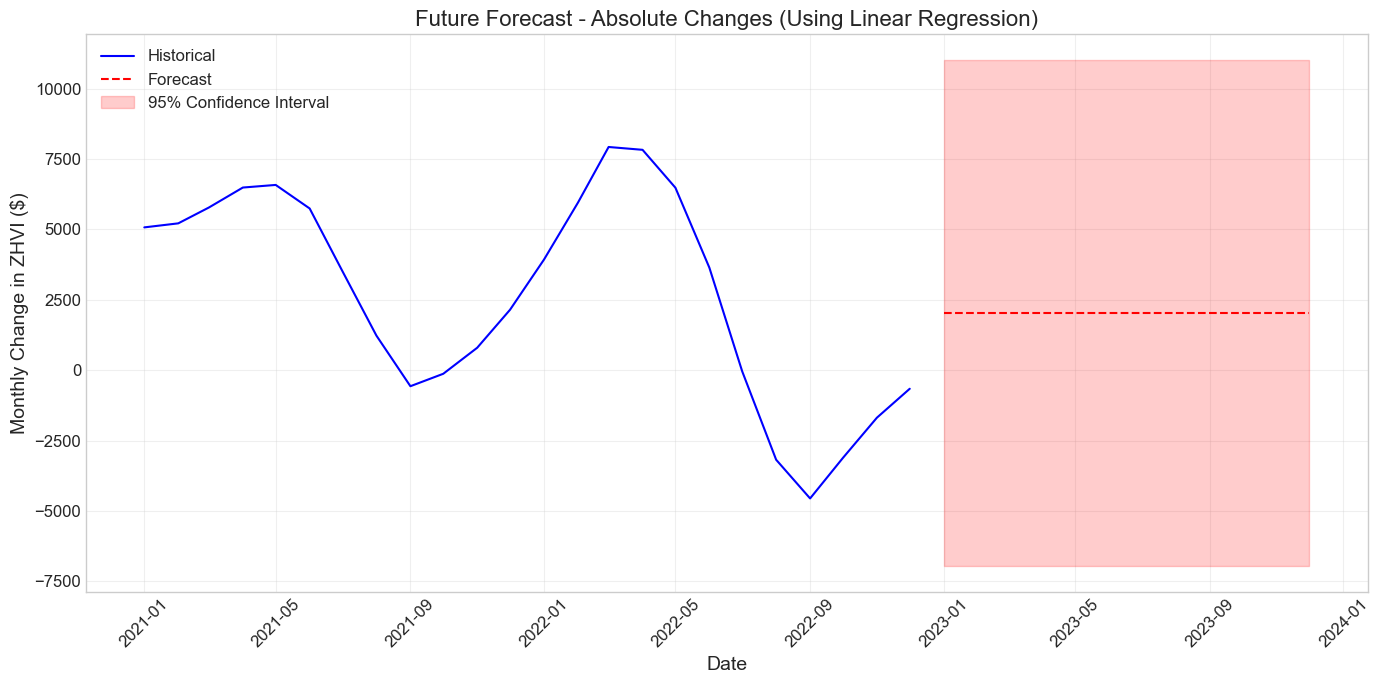

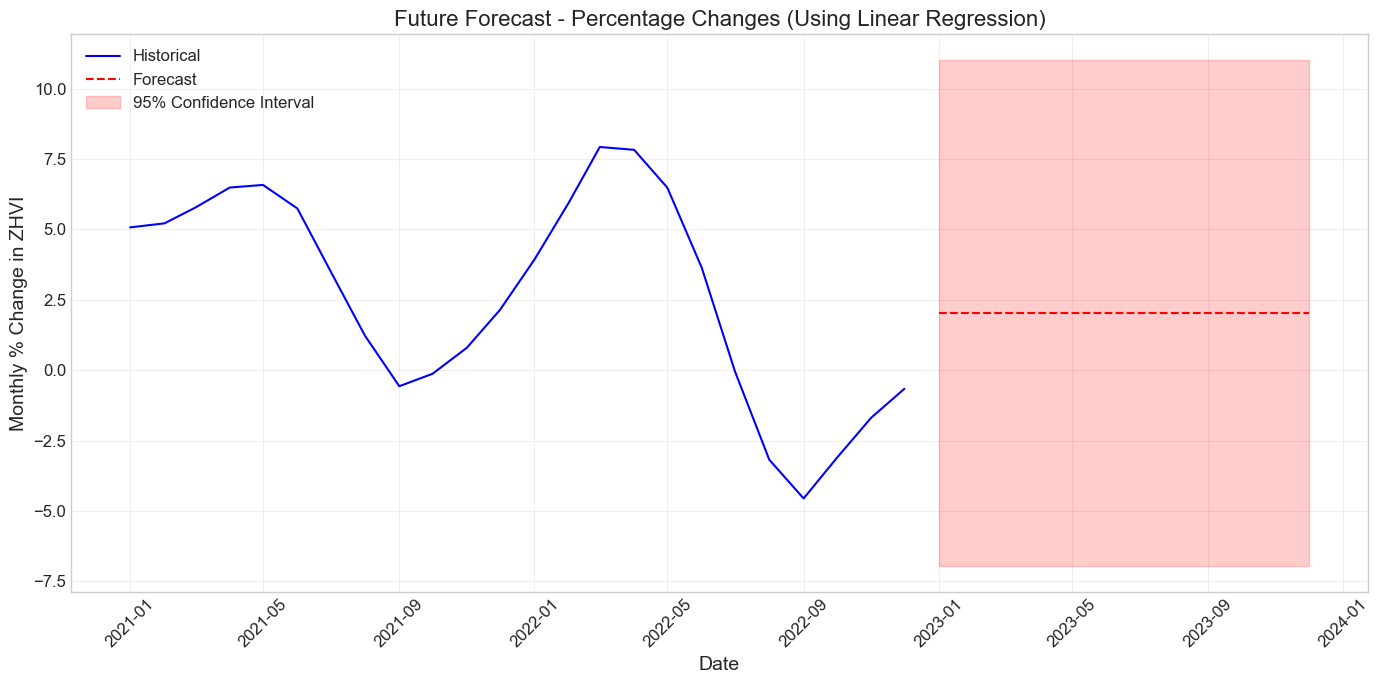

In [25]:
def create_future_dataset(last_date, horizon=12, features=None):
    """Create a dataset for future predictions by projecting feature values"""
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=31), periods=horizon, freq='MS')
    future_df = pd.DataFrame(index=future_dates)
    
    # Simple projections for each feature
    if features is not None:
        # Get the last few values for each feature
        last_values = df[features].iloc[-12:].mean()
        
        # Set all features to their mean value from the last 12 months
        for feature in features:
            future_df[feature] = last_values[feature]
    
    return future_df

# Try to generate forecasts only if we have successful models
try:
    # Create future dataset for next 12 months
    last_date = df.index.max()
    forecast_horizon = 12
    future_df = create_future_dataset(last_date, forecast_horizon, features)
    
    print(f"\nGenerating forecasts for the next {forecast_horizon} months...")
    print(f"Forecast period: {future_df.index.min().strftime('%B %Y')} to {future_df.index.max().strftime('%B %Y')}")
    
    # For absolute changes, use the best model if available
    if final_model_abs_name != "No successful model":
        # Scale future features
        future_features_scaled = scaler_X.transform(future_df[features])
        
        # Pick the appropriate model object
        if "Ridge" in final_model_abs_name or "Linear" in final_model_abs_name or "Lasso" in final_model_abs_name or "ElasticNet" in final_model_abs_name:
            model_obj = best_linear_model_obj_abs
        elif "Forest" in final_model_abs_name or "Boosting" in final_model_abs_name or "SVR" in final_model_abs_name or "Neural" in final_model_abs_name:
            model_obj = best_nonlinear_model_obj_abs
        elif "Ensemble" in final_model_abs_name:
            model_obj = ensemble_model_abs
        else:
            # Use a default fallback if needed
            model_obj = best_linear_model_obj_abs if 'best_linear_model_obj_abs' in locals() else None
        
        if model_obj is not None:
            # Generate forecast
            forecast_abs_scaled = model_obj.predict(future_features_scaled)
            forecast_abs = scaler_y_abs.inverse_transform(forecast_abs_scaled.reshape(-1, 1)).ravel()
            
            # Plot forecast
            plt.figure(figsize=(14, 7))
            plt.plot(df.index[-24:], df[target_abs].iloc[-24:], label='Historical', color='blue')
            plt.plot(future_df.index, forecast_abs, label='Forecast', color='red', linestyle='--')
            
            # Add confidence intervals (simplified)
            std_dev = df[target_abs].iloc[-12:].std()
            plt.fill_between(future_df.index, 
                             forecast_abs - 1.96*std_dev, 
                             forecast_abs + 1.96*std_dev, 
                             color='red', alpha=0.2, label='95% Confidence Interval')
            
            plt.title(f'Future Forecast - Absolute Changes (Using {final_model_abs_name})', fontsize=16)
            plt.xlabel('Date', fontsize=14)
            plt.ylabel('Monthly Change in ZHVI ($)', fontsize=14)
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.savefig('outputs/models/future_forecast_abs.png', dpi=300, bbox_inches='tight')
            plt.show()
    
    # For percentage changes, use the best model if available
    if final_model_pct_name != "No successful model":
        # Scale future features
        future_features_scaled = scaler_X.transform(future_df[features])
        
        # Pick the appropriate model object
        if "Ridge" in final_model_pct_name or "Linear" in final_model_pct_name or "Lasso" in final_model_pct_name or "ElasticNet" in final_model_pct_name:
            model_obj = best_linear_model_obj_pct
        elif "Forest" in final_model_pct_name or "Boosting" in final_model_pct_name or "SVR" in final_model_pct_name or "Neural" in final_model_pct_name:
            model_obj = best_nonlinear_model_obj_pct
        elif "Ensemble" in final_model_pct_name:
            model_obj = ensemble_model_pct
        else:
            # Use a default fallback if needed
            model_obj = best_linear_model_obj_pct if 'best_linear_model_obj_pct' in locals() else None
        
        if model_obj is not None:
            # Generate forecast
            forecast_pct_scaled = model_obj.predict(future_features_scaled)
            forecast_pct = scaler_y_pct.inverse_transform(forecast_pct_scaled.reshape(-1, 1)).ravel()
            
            # Plot forecast
            plt.figure(figsize=(14, 7))
            plt.plot(df.index[-24:], df[target_pct].iloc[-24:], label='Historical', color='blue')
            plt.plot(future_df.index, forecast_pct, label='Forecast', color='red', linestyle='--')
            
            # Add confidence intervals
            std_dev_pct = df[target_pct].iloc[-12:].std()
            plt.fill_between(future_df.index, 
                             forecast_pct - 1.96*std_dev_pct, 
                             forecast_pct + 1.96*std_dev_pct, 
                             color='red', alpha=0.2, label='95% Confidence Interval')
            
            plt.title(f'Future Forecast - Percentage Changes (Using {final_model_pct_name})', fontsize=16)
            plt.xlabel('Date', fontsize=14)
            plt.ylabel('Monthly % Change in ZHVI', fontsize=14)
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.savefig('outputs/models/future_forecast_pct.png', dpi=300, bbox_inches='tight')
            plt.show()
            
except Exception as e:
    print(f"Error generating forecasts: {str(e)}")
    print("Skipping forecast generation due to errors or lack of successful models.")


## 10. Conclusion and Recommendations

In [27]:
# Final summary
print("\n===== DC HOUSING MARKET FORECAST - SUMMARY =====")

print("\nKey Findings:")
if final_model_abs_name != "No successful model" and 'best_r2_abs' in locals():
    print(f"1. Best model for absolute changes: {final_model_abs_name}")
    print(f"   Performance metrics - R²: {best_r2_abs['R²']:.4f}, RMSE: ${best_r2_abs['RMSE']:.2f}")
else:
    print("1. No successful model for absolute changes")

if final_model_pct_name != "No successful model" and 'best_r2_pct' in locals():
    print(f"\n2. Best model for percentage changes: {final_model_pct_name}")
    print(f"   Performance metrics - R²: {best_r2_pct['R²']:.4f}, RMSE: {best_r2_pct['RMSE']:.2f}%")
else:
    print("2. No successful model for percentage changes")

print("\n3. Most important features for predicting housing price changes:")
if 'feature_importance_abs' in locals():
    print("   For absolute changes:")
    top_features = min(3, len(feature_importance_abs))
    for i in range(top_features):
        feature = feature_importance_abs['Feature'].iloc[i]
        importance = feature_importance_abs['Importance'].iloc[i]
        direction = '+' if feature_importance_abs['Direction'].iloc[i] > 0 else '-'
        print(f"   - {feature} ({direction}): {importance:.4f}")

if 'feature_importance_pct' in locals():
    print("\n   For percentage changes:")
    top_features = min(3, len(feature_importance_pct))
    for i in range(top_features):
        feature = feature_importance_pct['Feature'].iloc[i]
        importance = feature_importance_pct['Importance'].iloc[i]
        direction = '+' if feature_importance_pct['Direction'].iloc[i] > 0 else '-'
        print(f"   - {feature} ({direction}): {importance:.4f}")

print("\nRecommendations:")
print("1. Add more features to the dataset to improve predictive power")
print("2. Consider using more historical data if available")
print("3. Update models regularly as new data becomes available")
print("4. Explore alternative modeling approaches for the seasonally adjusted time series")
print("5. Consider separate models for different market regimes (rising rates vs. falling rates)")

print("\nNext Steps:")
print("1. Implement model monitoring to track forecast accuracy over time")
print("2. Develop neighborhood-level models for more granular predictions")
print("3. Incorporate additional economic indicators and housing market metrics")
print("4. Explore transformations of target variables for better model fit")


===== DC HOUSING MARKET FORECAST - SUMMARY =====

Key Findings:
1. Best model for absolute changes: Linear Regression
   Performance metrics - R²: 0.3764, RMSE: $3472.41

2. Best model for percentage changes: Linear Regression
   Performance metrics - R²: 0.3764, RMSE: 3.47%

3. Most important features for predicting housing price changes:
   For absolute changes:
   - CPI (-): 2.2906
   - Median_Household_Income (+): 2.0943
   - Unemployment_Rate_lag10 (+): 0.4288

   For percentage changes:
   - CPI (-): 2.2906
   - Median_Household_Income (+): 2.0943
   - Unemployment_Rate_lag10 (+): 0.4288

Recommendations:
1. Add more features to the dataset to improve predictive power
2. Consider using more historical data if available
3. Update models regularly as new data becomes available
4. Explore alternative modeling approaches for the seasonally adjusted time series
5. Consider separate models for different market regimes (rising rates vs. falling rates)

Next Steps:
1. Implement model mo

# Saving Results

In [28]:
# Save the results for future reference
try:
    all_results = {
        'absolute_change_results': all_results_df_abs.to_dict(orient='records') if not all_results_df_abs.empty else [],
        'percentage_change_results': all_results_df_pct.to_dict(orient='records') if not all_results_df_pct.empty else [],
        'best_model_abs': final_model_abs_name,
        'best_model_pct': final_model_pct_name,
    }
    
    # Add forecasts if available
    if 'forecast_abs' in locals():
        all_results['future_forecast_abs'] = list(forecast_abs)
        all_results['forecast_dates'] = [d.strftime('%Y-%m-%d') for d in future_df.index]
    if 'forecast_pct' in locals():
        all_results['future_forecast_pct'] = list(forecast_pct)
        if 'forecast_dates' not in all_results:
            all_results['forecast_dates'] = [d.strftime('%Y-%m-%d') for d in future_df.index]
    
    import json
    with open('outputs/models/forecast_results.json', 'w') as f:
        json.dump(all_results, f, indent=4)
    
    print("\nResults saved to outputs/models/forecast_results.json")
except Exception as e:
    print(f"Error saving results: {str(e)}")

print("\nAnalysis complete.")



Results saved to outputs/models/forecast_results.json

Analysis complete.
